## Laboratorio 2 - Regresión Lineal Multivariable

Este laboratorio utiliza el dataset "Airline Passenger Satisfaction"
obtenido de Kaggle. Contiene 42,758 registros de pasajeros de
aerolíneas con 22 variables como edad, distancia del vuelo,
calidad del servicio y retrasos. El objetivo es predecir el
retraso de llegada en minutos usando tres modelos de regresión lineal.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot

# Cargar dataset — archivo Excel
df = pd.read_excel('/content/drive/MyDrive/SIS420/DataSet3.xlsx')

# Exploración básica
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'\nColumnas disponibles:')
print(df.columns.tolist())
print(f'\nPrimeras filas:')
print(df.head())

Filas: 42886
Columnas: 25

Columnas disponibles:
['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']

Primeras filas:
   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Fli

In [6]:
# 1. Eliminar columnas innecesarias
df = df.drop(columns=['Unnamed: 0', 'id'])

# 2. Eliminar filas con nulos en Arrival Delay
df = df.dropna(subset=['Arrival Delay in Minutes'])
print(f'Filas después de limpiar: {df.shape[0]}')

# 3. Convertir columnas categóricas a números
df['Gender']           = (df['Gender'] == 'Male').astype(int)
df['Customer Type']    = (df['Customer Type'] == 'Loyal Customer').astype(int)
df['Type of Travel']   = (df['Type of Travel'] == 'Business travel').astype(int)
df['Class']            = df['Class'].map({'Business': 2, 'Eco Plus': 1, 'Eco': 0})
df['satisfaction']     = (df['satisfaction'] == 'satisfied').astype(int)

print(df.head())
print(f'\nTipos de datos:')
print(df.dtypes)

Filas después de limpiar: 42758
   Gender  Customer Type  Age  Type of Travel  Class  Flight Distance  \
0       1              1   13               0      1              460   
1       1              0   25               1      2              235   
2       0              1   26               1      2             1142   
3       0              1   25               1      2              562   
4       1              1   61               1      2              214   

   Inflight wifi service  Departure/Arrival time convenient  \
0                      3                                  4   
1                      3                                  2   
2                      2                                  2   
3                      2                                  5   
4                      3                                  3   

   Ease of Online booking  Gate location  ...  Inflight entertainment  \
0                       3              1  ...                       5   
1   

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar X e y
X = df.drop(columns=['Arrival Delay in Minutes']).to_numpy()
y = df['Arrival Delay in Minutes'].to_numpy()

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nEjemplos de y (retrasos en minutos):')
print(f'  Min:      {y.min():.0f} min')
print(f'  Max:      {y.max():.0f} min')
print(f'  Promedio: {y.mean():.1f} min')

# Dividir 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'\nEntrenamiento: {X_train.shape[0]} ejemplos')
print(f'Prueba:        {X_test.shape[0]} ejemplos')

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Agregar columna de unos
X_train_b = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_b  = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

print(f'\nShape X_train final: {X_train_b.shape}')
print(f'Shape X_test final:  {X_test_b.shape}')

Shape X: (42758, 22)
Shape y: (42758,)

Ejemplos de y (retrasos en minutos):
  Min:      0 min
  Max:      1280 min
  Promedio: 15.2 min

Entrenamiento: 34206 ejemplos
Prueba:        8552 ejemplos

Shape X_train final: (34206, 23)
Shape X_test final:  (8552, 23)


## Preprocesamiento con Pandas

Se eliminaron columnas irrelevantes como 'id' y 'Unnamed: 0'.
Se convirtieron variables categóricas (Gender, Class, Type of Travel,
etc.) a valores numéricos. Se eliminaron 128 filas con valores nulos
en 'Arrival Delay in Minutes'. Los datos se dividieron en 80%
entrenamiento (34,206 ejemplos) y 20% prueba (8,552 ejemplos).
Finalmente se normalizaron las variables con StandardScaler.

In [8]:
def calcularCosto(X, y, theta):
    m = y.size
    # Diferencia entre predicción y valor real
    error = np.dot(X, theta) - y
    # Promedio del error cuadrado
    J = (1/(2*m)) * np.sum(np.square(error))
    return J

def gradientDescent(X, y, theta, alpha, num_iters):
    m = y.size
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        # Actualizar todos los thetas simultáneamente
        error = np.dot(X, theta) - y
        theta = theta - (alpha/m) * X.T.dot(error)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

## Regresión Lineal Multivariable

Se implementó gradient descent con alpha=0.1 y 1,500 iteraciones
usando las 22 variables del dataset. El costo bajó de 699.83 a 50.81,
una mejora del 92.7%. El error promedio en datos de prueba fue de
5.18 minutos sobre un retraso promedio de 15.2 minutos.

In [18]:
# Theta inicial en ceros — ahora son 23 thetas (uno por variable + bias)
theta_inicial = np.zeros(X_train_b.shape[1])

# Parámetros
alpha = 0.1
num_iters = 30000

# Entrenar
theta, J_history = gradientDescent(
    X_train_b, y_train, theta_inicial, alpha, num_iters)

print(f'Costo inicial: {J_history[0]:.2f}')
print(f'Costo final:   {J_history[-1]:.2f}')

Costo inicial: 699.83
Costo final:   50.81


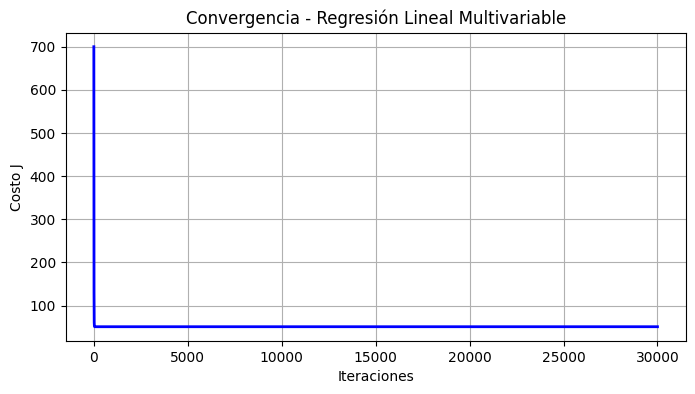

In [19]:
pyplot.figure(figsize=(8,4))
pyplot.plot(J_history, 'b-', lw=2)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia - Regresión Lineal Multivariable')
pyplot.grid(True)
pyplot.show()

In [20]:
# Predicciones en datos de prueba
y_pred = np.dot(X_test_b, theta)

# Error promedio absoluto
mae = np.abs(y_pred - y_test).mean()
print(f'Error promedio absoluto: {mae:.2f} minutos')

# Comparar primeras 10 predicciones vs valores reales
print(f'\nComparación predicción vs real:')
print(f'{"Real":>10} {"Predicho":>10} {"Error":>10}')
for i in range(10):
    error = abs(y_pred[i] - y_test[i])
    print(f'{y_test[i]:>10.1f} {y_pred[i]:>10.1f} {error:>10.1f}')

Error promedio absoluto: 5.18 minutos

Comparación predicción vs real:
      Real   Predicho      Error
       0.0        0.5        0.5
       0.0        0.2        0.2
       0.0        1.7        1.7
       0.0        0.9        0.9
       0.0        3.3        3.3
       0.0        0.5        0.5
       0.0        1.1        1.1
     121.0       92.6       28.4
      10.0        2.0        8.0
       0.0       -0.3        0.3


## Regresión Polinómica

Se agregaron términos de grado 2 expandiendo de 22 a 275
características. El costo final fue 49.62, levemente mejor
que el modelo lineal. Sin embargo el error promedio fue 5.32
minutos, ligeramente peor en datos nuevos, indicando que
la relación entre las variables y el retraso es principalmente lineal.

In [21]:
from sklearn.preprocessing import PolynomialFeatures

# Crear características polinómicas de grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)

# Aplicar a datos de entrenamiento y prueba
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

print(f'Variables originales:    {X_train_scaled.shape[1]}')
print(f'Variables polinómicas:   {X_train_poly.shape[1]}')

# Agregar columna de unos
X_train_poly_b = np.hstack([np.ones((X_train_poly.shape[0], 1)), X_train_poly])
X_test_poly_b  = np.hstack([np.ones((X_test_poly.shape[0], 1)), X_test_poly])

# Normalizar las nuevas características
scaler_poly = StandardScaler()
X_train_poly_b[:, 1:] = scaler_poly.fit_transform(X_train_poly_b[:, 1:])
X_test_poly_b[:, 1:]  = scaler_poly.transform(X_test_poly_b[:, 1:])

Variables originales:    22
Variables polinómicas:   275


In [24]:
theta_poly = np.zeros(X_train_poly_b.shape[1])
alpha = 0.1
num_iters = 15000

theta_poly, J_history_poly = gradientDescent(
    X_train_poly_b, y_train, theta_poly, alpha, num_iters)

print(f'Costo inicial: {J_history_poly[0]:.2f}')
print(f'Costo final:   {J_history_poly[-1]:.2f}')

Costo inicial: 616.32
Costo final:   49.62


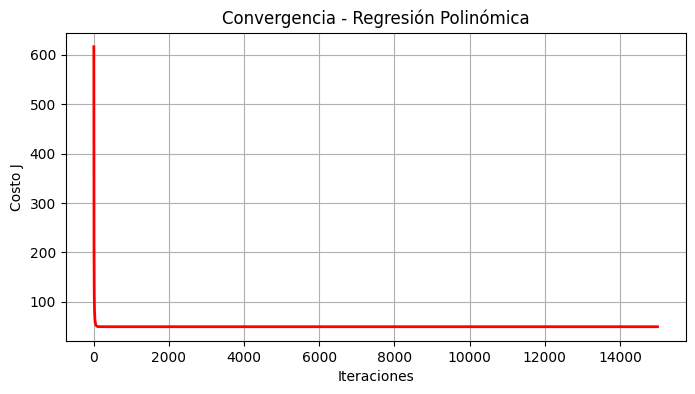

In [25]:
pyplot.figure(figsize=(8,4))
pyplot.plot(J_history_poly, 'r-', lw=2)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia - Regresión Polinómica')
pyplot.grid(True)
pyplot.show()

In [26]:
# Predicciones modelo polinómico
y_pred_poly = np.dot(X_test_poly_b, theta_poly)

# Error promedio absoluto
mae_poly = np.abs(y_pred_poly - y_test).mean()
print(f'Error promedio absoluto polinómico: {mae_poly:.2f} minutos')

# Comparar primeras 10 predicciones
print(f'\nComparación predicción vs real:')
print(f'{"Real":>10} {"Lineal":>10} {"Polinómico":>12} {"Error":>10}')
for i in range(10):
    error = abs(y_pred_poly[i] - y_test[i])
    print(f'{y_test[i]:>10.1f} {y_pred[i]:>10.1f} {y_pred_poly[i]:>12.1f} {error:>10.1f}')

Error promedio absoluto polinómico: 5.32 minutos

Comparación predicción vs real:
      Real     Lineal   Polinómico      Error
       0.0        0.5          2.8        2.8
       0.0        0.2          1.0        1.0
       0.0        1.7          3.8        3.8
       0.0        0.9          2.3        2.3
       0.0        3.3          3.8        3.8
       0.0        0.5          0.2        0.2
       0.0        1.1          1.4        1.4
     121.0       92.6         90.2       30.8
      10.0        2.0          2.4        7.6
       0.0       -0.3          1.0        1.0


## Ecuación Normal

La ecuación normal calcula theta directamente con la fórmula
θ = (XᵀX)⁻¹Xᵀy sin necesidad de iteraciones ni alpha.
El costo obtenido fue 50.81 y el error promedio 5.18 minutos,
idénticos al modelo lineal multivariable, confirmando que
gradient descent convergió correctamente.

In [27]:
def ecuacionNormal(X, y):
    # θ = (XᵀX)⁻¹ Xᵀy
    # np.linalg.pinv calcula la pseudoinversa
    # más estable que inv para matrices grandes
    theta = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

# Calcular theta directamente sin iteraciones
theta_normal = ecuacionNormal(X_train_b, y_train)

# Costo con theta encontrado
costo_normal = calcularCosto(X_train_b, y_train, theta_normal)
print(f'Costo ecuación normal: {costo_normal:.2f}')

# Predicciones
y_pred_normal = np.dot(X_test_b, theta_normal)

# Error promedio
mae_normal = np.abs(y_pred_normal - y_test).mean()
print(f'Error promedio absoluto: {mae_normal:.2f} minutos')

Costo ecuación normal: 50.81
Error promedio absoluto: 5.18 minutos


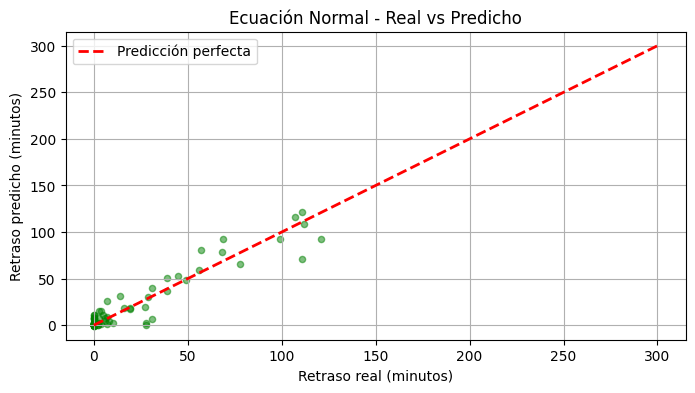

In [28]:
pyplot.figure(figsize=(8,4))
pyplot.scatter(y_test[:100], y_pred_normal[:100],
               alpha=0.5, color='green', s=20)
pyplot.plot([0, 300], [0, 300], 'r--', lw=2, label='Predicción perfecta')
pyplot.xlabel('Retraso real (minutos)')
pyplot.ylabel('Retraso predicho (minutos)')
pyplot.title('Ecuación Normal - Real vs Predicho')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

## Predicciones

Se realizaron 100 predicciones comparando los tres modelos.
El modelo es más preciso en vuelos puntuales (retraso=0)
y subestima ligeramente los retrasos extremos.
La regresión lineal y la ecuación normal obtuvieron
resultados idénticos con error promedio de 5.18 minutos.

In [29]:
# 100 predicciones con ecuación normal
y_pred_100 = np.dot(X_test_b[:100], theta_normal)

print(f'{"#":>4} {"Real":>8} {"Lineal":>8} {"Polinómico":>12} {"Normal":>8}')
print('-' * 45)
for i in range(100):
    print(f'{i+1:>4} {y_test[i]:>8.1f} {y_pred[i]:>8.1f} '
          f'{y_pred_poly[i]:>12.1f} {y_pred_100[i]:>8.1f}')

   #     Real   Lineal   Polinómico   Normal
---------------------------------------------
   1      0.0      0.5          2.8      0.5
   2      0.0      0.2          1.0      0.2
   3      0.0      1.7          3.8      1.7
   4      0.0      0.9          2.3      0.9
   5      0.0      3.3          3.8      3.3
   6      0.0      0.5          0.2      0.5
   7      0.0      1.1          1.4      1.1
   8    121.0     92.6         90.2     92.6
   9     10.0      2.0          2.4      2.0
  10      0.0     -0.3          1.0     -0.3
  11      3.0      7.6          8.1      7.6
  12      0.0      0.1         -0.7      0.1
  13      0.0      0.2          0.3      0.2
  14      7.0      0.7          2.2      0.7
  15      0.0      1.7         -0.2      1.7
  16      0.0     -0.4         -0.9     -0.4
  17      0.0      1.4          1.9      1.4
  18     19.0     17.2         17.0     17.2
  19      0.0      8.1          9.2      8.1
  20      0.0      2.4          2.2      2.4
  21     

## Conclusiones

Los tres modelos demostraron ser efectivos para predecir retrasos
con error promedio de ~5 minutos. La regresión lineal multivariable
y la ecuación normal obtuvieron los mejores resultados.
La regresión polinómica no mejoró significativamente, confirmando
que las relaciones en el dataset son principalmente lineales.